# Advanced model fitting: calibrating the MONARCH model

## Introduction
The goal of this notebook is to calibrate our lab's MONARCH model to a synthetic data set, as published in Jones & Oomen [1]. We will generate a synthetic data set using MONARCH and calibrate the model to this synthetic data using CHAMLEON to check if we can recapitulate the known model parameters. We will calibrate a single heart beat simulation as well as a growth simulation. The outline will be:
1. Generating the synthetic data
2. Fitting the baseline model
3. Fitting the chronic model

In [1]:
# Enable automatically reloading modules when they have changed
%load_ext autoreload
%autoreload 2

When rerunning this notebook, set the run_sims variable to false to skip the simulation step and only run the GPEs and implausibility calculations. Simulations ran previously will be loaded and this will tremendously speed up the process.

In [2]:
import pathlib

main_dir = pathlib.Path.cwd() / "demo_monarch"
run_sims = True

## Generating the synthetic data
### Running simulation
The MONARCH model platform is a system of ordinary differential equations (ODEs) that describes cardiac physiology, mechanics and growth. The model is described in detail in [1]. First, import the model and initialize it with the default parameters from an input file designed to simulate volume overload in canines (from MONARCH's GitHub repository).

In [3]:
from monarch import Hatch

# Initialize model
input_vo = "P365_Nx"
beats = Hatch(input_vo)

We want to set a few constants to ensure a realistic wall geometry of all ventricles at all times. This is important because we only want to fit the LV parameters in this case, and want to have realistic geometries for the other chambers for every chosen parameter set. These constants include a ratio of midwall reference areas takes from [2], and the wall thicknesses of all other chambers than the LV at end-diastole from [3].

In [4]:
model_constants = {"ratio_amref_lfw": 0.77, "ratio_amref_ww": 0.41, "ratio_amref_la": 0.54, "ratio_amref_ra": 0.39,
                   "ratio_wv_lfw": 3.2, "ratio_wv_ww": 1.6, "ratio_wv_la": 0.30, "ratio_wv_ra": 0.13}

beats.change_pars(model_constants)

In [5]:
#beats.clear_converged_sol()
beats.just_beat_it(print_solve=True)

Iteration 0:	8.03e-01 1.23e+01 8.42e-03 5.02e-01 1.26e-01 2.86e+00 3.02e-01 2.92e-01
Iteration 1:	3.74e-01 9.09e-02 1.14e-01 3.07e-01 5.31e-02 8.75e-03 1.82e-01 2.70e-02
Iteration 2:	1.45e-01 2.20e-02 1.64e-02 6.11e-02 1.41e-02 1.95e-03 1.79e-02 5.44e-02
Iteration 3:	2.96e-02 4.59e-03 3.86e-03 7.71e-03 8.17e-03 1.24e-03 2.24e-03 2.74e-02
Iteration 4:	4.22e-03 2.51e-04 1.51e-04 2.59e-04 6.56e-03 9.91e-04 6.03e-04 1.46e-02
Iteration 5:	1.36e-02 1.63e-03 1.31e-03 7.15e-05 5.53e-03 8.33e-04 1.59e-03 8.95e-03
Iteration 6:	1.50e-02 1.90e-03 1.52e-03 9.12e-04 4.63e-03 6.97e-04 1.80e-03 6.18e-03
Iteration 7:	1.39e-02 1.79e-03 1.42e-03 1.29e-03 3.83e-03 5.76e-04 1.69e-03 4.59e-03
Iteration 8:	1.21e-02 1.58e-03 1.23e-03 1.32e-03 3.14e-03 4.72e-04 1.48e-03 3.56e-03
Iteration 9:	1.02e-02 1.34e-03 1.04e-03 1.20e-03 2.57e-03 3.86e-04 1.25e-03 2.83e-03
Iteration 10:	8.50e-03 1.13e-03 8.61e-04 1.04e-03 2.10e-03 3.15e-04 1.03e-03 2.27e-03
Steady-state circulation established


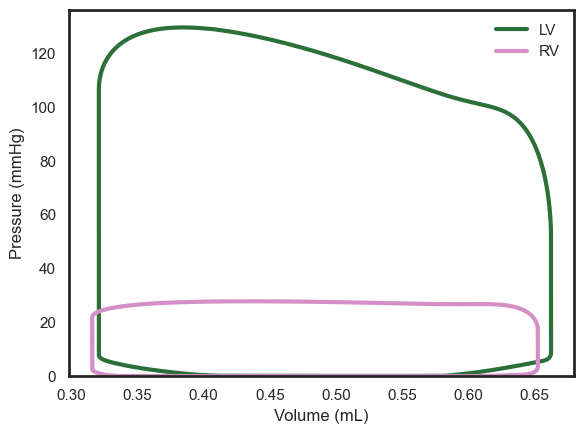

In [6]:
# Import plotting functions
import monarch.metamorphoses as meta

# Plot LV pressure-volume loop
meta.pv_loop(beats, compartments=("LV", "RV"))

In [7]:
beats.outputs.RVSV

0    0.336831
Name: RVSV, dtype: float64

In [8]:
beats.outputs.RVMaxP

0    27.87766
Name: RVMaxP, dtype: float64

In [9]:
beats.outputs.RVEDP

0    3.717224
Name: RVEDP, dtype: float64

In [10]:
beats.outputs.RVESV

0    0.315775
Name: RVESV, dtype: float64

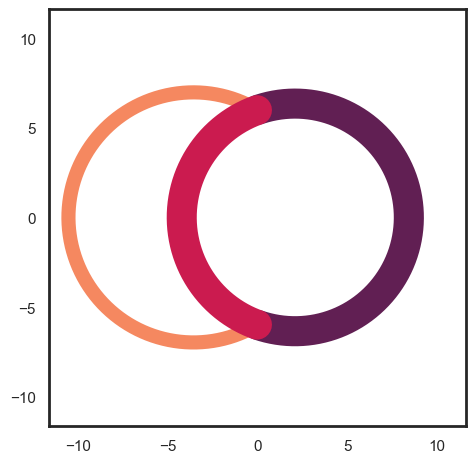

In [11]:
meta.cardiac_geometry(beats, real_wall_thickness=True)

#### Baseline
CHAMELEON's Camouflage class is expecting a Pandas dataframe with all information for each output variable, which we set up here. We need `mu` (mean) and `sigma` (standard deviation), and optional the lower and upper limits labeled as `min` and `max`, resp. The time point of needs to be specified by `_label`, for a non-growth simulation this can be `_baseline` and/or `_acute`. We provide a utility function to convert the data to this format, and save it as a .csv file for documentation.

In [12]:
from chameleon.utils import convert_data
import pandas as pd

roi_baseline = ["RVEDV", "RVESV", "RVEDP", "RVESP","RVSV"]


data_baseline = pd.read_csv("demo_monarch/data/data_baseline_P365_Nx.csv",index_col=0)
data_baseline

,mu_baseline,sigma_baseline,min,max
RVEDV,0.641,0.181,0.268,0.950
RVESV,0.272,0.117,0.092,0.455
RVEDP,2.600,1.100,0.300,4.500
RVMaxP,22.000,4.200,13.000,32.000
RVSV,0.357,0.094,0.161,0.528


## Global sensitivity analysis
Before running the BHM, it is good practice to perform a sensitivity analysis. This can help you identify parameters or readouts that are irrelevant to the fitting process, and thus can be excluded from the fitting process and set constant. We will use the SALib package to perform a Sobol sensitivity analysis. In most models, performing a global sensitivity analysis is computationally expensive, so here take advantage of the low computational cost of the emulators to perform the analysis. 

First, decide what parameters to fit and what their expected ranges are, and compile them in a list of dictionaries (one for each parameter). It is crucial that the labels match (case-insensitive) the label names in MONARCH's change_pars function. A list of the supported parameters can be called using `monarch.utils.list_change_pars`.

In [13]:
pars = {
        "SAct": {"limits": [0.050, 1]},
        "AmRefLfw": {"limits": [250, 450]},
        "AmRefRfw": {"limits": [350, 550]},
        "AmRefSfw": {"limits": [150, 200]},
        "c3": {"limits": [5e-4, 5e-2]},
        "VLfw": {"limits": [500, 650]},
        "VRfw": {"limits": [300, 450]},
        "VSfw": {"limits": [250, 350]},
        "SBV": {"limits": [2, 9]},
        "Rvp": {"limits": [0.01, 10]},
        "Rcs": {"limits": [1, 20]},
        "Ras": {"limits": [30, 90]},
        "Rvs": {"limits": [0.01, 5]},
        "Rcp": {"limits": [0.10, 10]},
        "Rap": {"limits": [1, 20]},
        "Rav": {"limits": [0.05, 5]},
        "Cvp": {"limits": [0.1e-2, 10e-2]},
        "Cas": {"limits": [1e-3, 10e-3]},
        "Cvs": {"limits": [0.1e-1, 10e-1]},
        "Cap": {"limits": [1e-2, 10e-2]},
        "sfact": {"limits": [0.05, 1]},
    }

Set up the Camouflage class, making sure to run sufficient simulations to properly train the emulators. Similarly, use enough emulation points to get a good estimate of the Sobol indices. A minimum of `n_emu0` = $2^{11}$ = 2048 is generally recommended in the literature for this, so we go one order higher ($2^{12}$) just to be sure.


In [14]:
from chameleon import Camouflage

# Set up directories to store results
sense_dir = main_dir / "sensitivity"

# Setting up the wave class
wave = Camouflage(0, sense_dir, 5.0, pars, data_baseline, nroy=None, n_sim=2**8,
                  clear_log=True, n_emu0=2**12, n_emu_min=2**12)

-----------
Parameters:
-----------
- SAct: [0.05 - 1.0]
- AmRefLfw: [250.0 - 450.0]
- AmRefRfw: [350.0 - 550.0]
- AmRefSfw: [150.0 - 200.0]
- c3: [0.0005 - 0.05]
- VLfw: [500.0 - 650.0]
- VRfw: [300.0 - 450.0]
- VSfw: [250.0 - 350.0]
- SBV: [2.0 - 9.0]
- Rvp: [0.01 - 10.0]
- Rcs: [1.0 - 20.0]
- Ras: [30.0 - 90.0]
- Rvs: [0.01 - 5.0]
- Rcp: [0.1 - 10.0]
- Rap: [1.0 - 20.0]
- Rav: [0.05 - 5.0]
- Cvp: [0.001 - 0.1]
- Cas: [0.001 - 0.01]
- Cvs: [0.01 - 1.0]
- Cap: [0.01 - 0.1]
- sfact: [0.05 - 1.0]


-------------
Observations:
-------------
- RVEDV: 0.641 ± 0.181
- RVESV: 0.272 ± 0.117
- RVEDP: 2.6 ± 1.1
- RVMaxP: 22.0 ± 4.2
- RVSV: 0.357 ± 0.094


-------------
Constants:
-------------
None specified



------
Wave 1
------
Generated emulation point cloud with 4096 points


Now we will run model simulations to train the emulators. Depending on your computer, this may take several minutes. The results will be stored in the `sense_dir` / "Wave 1" directory. In contrast to the simple example in the sister notebook *simple_model*, we will need more advanced functions to run the simulations with each selected parameter set, and to obtain the output results. We will therefore included a module named `monarch_utils` that contains these functions, wrapped together in a function called `run_forest_run`. This function will run the simulations, store the results in `wave.sim_dir` (Default name "Wave #" / "sims"), and return the output results in a format that can be used by the Camouflage class. 

>Important: you can create your own version of the `monarch_utils` module to run any model of your choice, as long as it returns `x_sim` and `y_sim` in the correct format, i.e. numpy arrays with each row representing a parameter set and each column representing a different output variable, in the same order as `wave.x_names`.

Note that when running the models with the cell below, several models will not converge, throwing warning. This is expected since we are running the model with a very broad parameter space, some of which result in unrealistic and unstable solutions. This is not a problem, since the implausible parameter sets will be filtered out in the BHM process later. Running the cel will take several seconds-minutes, depending on your computer. You can set `run_sims` to false if rerunning this cell/notebook to save time.

In [15]:
import chameleon.monarch_utils as monarch_utils

# Run simulations for all parameter sets in current wave set x to train the emulators
wave.x_sim, wave.y_sim, _ = monarch_utils.run_forest_run(wave, input_vo, [], run_sims=run_sims,
                                                              log_file=wave.log_file)

wave.x_sim, wave.y_sim, _ = monarch_utils.run_forest_run(wave, input_vo, [], run_sims=run_sims,
                                                              constants=model_constants, log_file=wave.log_file)

Running 256 model simulations...
256 simulations completed in 67.87 seconds
254 Simulations reached convergence


C:\Users\salla\Documents\GitHub\chameleon\src\chameleon\utils.py:92: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.772038035674051e-20.
  inv_covmat = sp.linalg.inv(cov)  # Inverse covariance


238 Simulations added to training data
Running 238 model simulations...
238 simulations completed in 74.21 seconds
238 Simulations reached convergence


C:\Users\salla\Documents\GitHub\chameleon\src\chameleon\utils.py:92: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.639022720209013e-20.
  inv_covmat = sp.linalg.inv(cov)  # Inverse covariance


236 Simulations added to training data


Use the wrapper function to run the Sobol sensitivity analysis. This will take a while, depending on your computer.

In [16]:
# Wrapper to run gpe_training_validation and sobol_sensitivity
wave.surf_sensitivity()

Performing sensitivity analysis...
Emulating 4096 points...
Emulation completed in 40.81 seconds


Now we plot the results of the global sensitivity analysis.

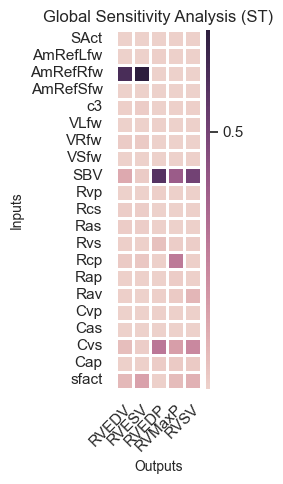

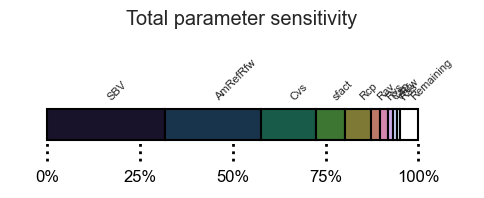

In [17]:
from chameleon import TrueColors

# Initialize TrueColors class
camo = TrueColors(sense_dir)

camo.plot_sensitivity_matrix(show_fig=True)
camo.plot_sensitivity_total(show_bar=True, cutoff=0.95)

In [18]:
pars = {
        "AmRefRfw": {"limits": [425, 525]},
        "Cvs": {"limits": [1e-1, 15e-1]},
        "Rap": {"limits": [2, 15]},
        "sfact": {"limits": [0.2, 1]},
        "c3": {"limits": [5e-5, 5e-2]},
    }

Note that the sensitivity analysis shows that the parameter `c3` is not sensitive to any of the outputs. We will therefore exclude this parameter from the fitting process. `S_act` is on the brink of being excluded too, but we will keep it in for now.

## Calibrating the baseline model
### Run calibration
First, we store the true values of the parameters in a csv file to record and compare with the fitted values later.

We now run the entire BHM process, see the `simple_model` notebook for more details on this code fragment. Running this will take several minutes, depending on your computer. By default, we will utilize all but one CPUs on your computer. Note that, just like in the sensitivity analysis, many simulation in the early waves will crash because some very unrealistic parameter sets are included, but in later waves the model will behave much better since only non-implausible parameters sets are retained.

In [19]:
# Storage directory
baseline_dir = main_dir / "baseline"

# Initialize wave index
i_wave = 0
nroy = None
not_flooded = True
sim_dirs = []

# Start history matching until convergence is reached
while not_flooded:

    # Set wave threshold: start with 5.0 and reduce incrementally with steps of 0.5 until 2.0
    wave_threshold = max(5 - 1*i_wave, 2)
    
    # Initialize wave    
    wave = Camouflage(i_wave, baseline_dir, wave_threshold, pars, data_baseline, nroy=nroy, clear_log=(i_wave == 0), 
                constants=model_constants, n_emu0=2**18)
    
    #wave = Camouflage(i_wave, baseline_dir, wave_threshold, pars, data_baseline, nroy=nroy, clear_log=(i_wave == 0), 
    #            n_emu0=2**18)

    # Run simulations for all parameter sets in current wave set
    wave.x_sim, wave.y_sim, sim_dirs = monarch_utils.run_forest_run(wave, input_vo, sim_dirs, constants=model_constants, 
                                                                  log_file=wave.log_file, run_sims=run_sims)
    
    #wave.x_sim, wave.y_sim, sim_dirs = monarch_utils.run_forest_run(wave, input_vo, sim_dirs,
    #                                                              log_file=wave.log_file, run_sims=run_sims)

    # Run wave: train/validate emulators, emulate, calculate implausibility, find NROY
    wave.surf()

    # Check for convergence, store NROY from this wave as NROY for the next wave and update counter
    not_flooded = wave.is_flooded(i_wave, min_waves=4, max_waves=5)
    nroy = wave.nroy
    i_wave += 1

-----------
Parameters:
-----------
- AmRefRfw: [425.0 - 525.0]
- Cvs: [0.1 - 1.5]
- Rap: [2.0 - 15.0]
- sfact: [0.2 - 1.0]
- c3: [5e-05 - 0.05]


-------------
Observations:
-------------
- RVEDV: 0.641 ± 0.181
- RVESV: 0.272 ± 0.117
- RVEDP: 2.6 ± 1.1
- RVMaxP: 22.0 ± 4.2
- RVSV: 0.357 ± 0.094


-------------
Constants:
-------------
- ratio_amref_lfw: 0.77
- ratio_amref_ww: 0.41
- ratio_amref_la: 0.54
- ratio_amref_ra: 0.39
- ratio_wv_lfw: 3.2
- ratio_wv_ww: 1.6
- ratio_wv_la: 0.3
- ratio_wv_ra: 0.13



------
Wave 1
------
Generated emulation point cloud with 262144 points
Running 128 model simulations...
128 simulations completed in 89.32 seconds
128 Simulations reached convergence


C:\Users\salla\Documents\GitHub\chameleon\src\chameleon\utils.py:92: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.570161184583081e-21.
  inv_covmat = sp.linalg.inv(cov)  # Inverse covariance
C:\Users\salla\Documents\GitHub\chameleon\src\chameleon\utils.py:95: RuntimeWarning: invalid value encountered in sqrt
  md = np.sqrt(mahal.diagonal())


103 Simulations added to training data
Emulating 262144 points...
Emulation completed in 1.14 seconds
262144 points remaining in NROY region (100.0% of original space)
RVESV is the most implausible output (39.58% of all points)
98796 points remaining in NROY region after limits check
NROY size change at Wave 1 is -0.62: no convergence

------
Wave 2
------
Regenerating emulation cloud from 98796 to 100000 points...
Running 128 model simulations...
128 simulations completed in 100.60 seconds
128 Simulations reached convergence


C:\Users\salla\Documents\GitHub\chameleon\src\chameleon\utils.py:92: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.58457687258153e-20.
  inv_covmat = sp.linalg.inv(cov)  # Inverse covariance


122 Simulations added to training data
Emulating 100000 points...
Emulation completed in 0.67 seconds
100000 points remaining in NROY region (38.15% of original space)
RVSV is the most implausible output (34.2% of all points)
96300 points remaining in NROY region after limits check
NROY size change is -0.03: convergence established but minimum number of waves (4) not yet reached

------
Wave 3
------
Regenerating emulation cloud from 96300 to 100000 points...
Running 128 model simulations...
128 simulations completed in 40.95 seconds
128 Simulations reached convergence


C:\Users\salla\Documents\GitHub\chameleon\src\chameleon\utils.py:92: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.6816183067019393e-20.
  inv_covmat = sp.linalg.inv(cov)  # Inverse covariance


121 Simulations added to training data
Emulating 100000 points...
Emulation completed in 1.14 seconds
99995 points remaining in NROY region (38.15% of original space)
RVSV is the most implausible output (36.77% of all points)
98050 points remaining in NROY region after limits check
NROY size change is 0.02: convergence established but minimum number of waves (4) not yet reached

------
Wave 4
------
Regenerating emulation cloud from 98050 to 100000 points...
Running 128 model simulations...
128 simulations completed in 43.59 seconds
128 Simulations reached convergence


C:\Users\salla\Documents\GitHub\chameleon\src\chameleon\utils.py:92: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 6.145097692298129e-20.
  inv_covmat = sp.linalg.inv(cov)  # Inverse covariance


121 Simulations added to training data
Emulating 100000 points...
Emulation completed in 1.85 seconds
94002 points remaining in NROY region (35.86% of original space)
RVSV is the most implausible output (36.24% of all points)
93405 points remaining in NROY region after limits check
NROY size change is -0.05: convergence established


### Analyzing the results
Run and plot simulations using a randomly selected subset of the posterior distribution. Compare these results with the simulation results after we just ran the single wave with implausibility criterion of 5.0 to see the vast improvement.


---------
Posterior
---------
Running 256 model simulations...
256 simulations completed in 55.42 seconds
256 Simulations reached convergence


C:\Users\salla\Documents\GitHub\chameleon\src\chameleon\utils.py:92: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.891088540912618e-21.
  inv_covmat = sp.linalg.inv(cov)  # Inverse covariance
C:\Users\salla\Documents\GitHub\chameleon\src\chameleon\utils.py:95: RuntimeWarning: invalid value encountered in sqrt
  md = np.sqrt(mahal.diagonal())


238 Simulations added to training data


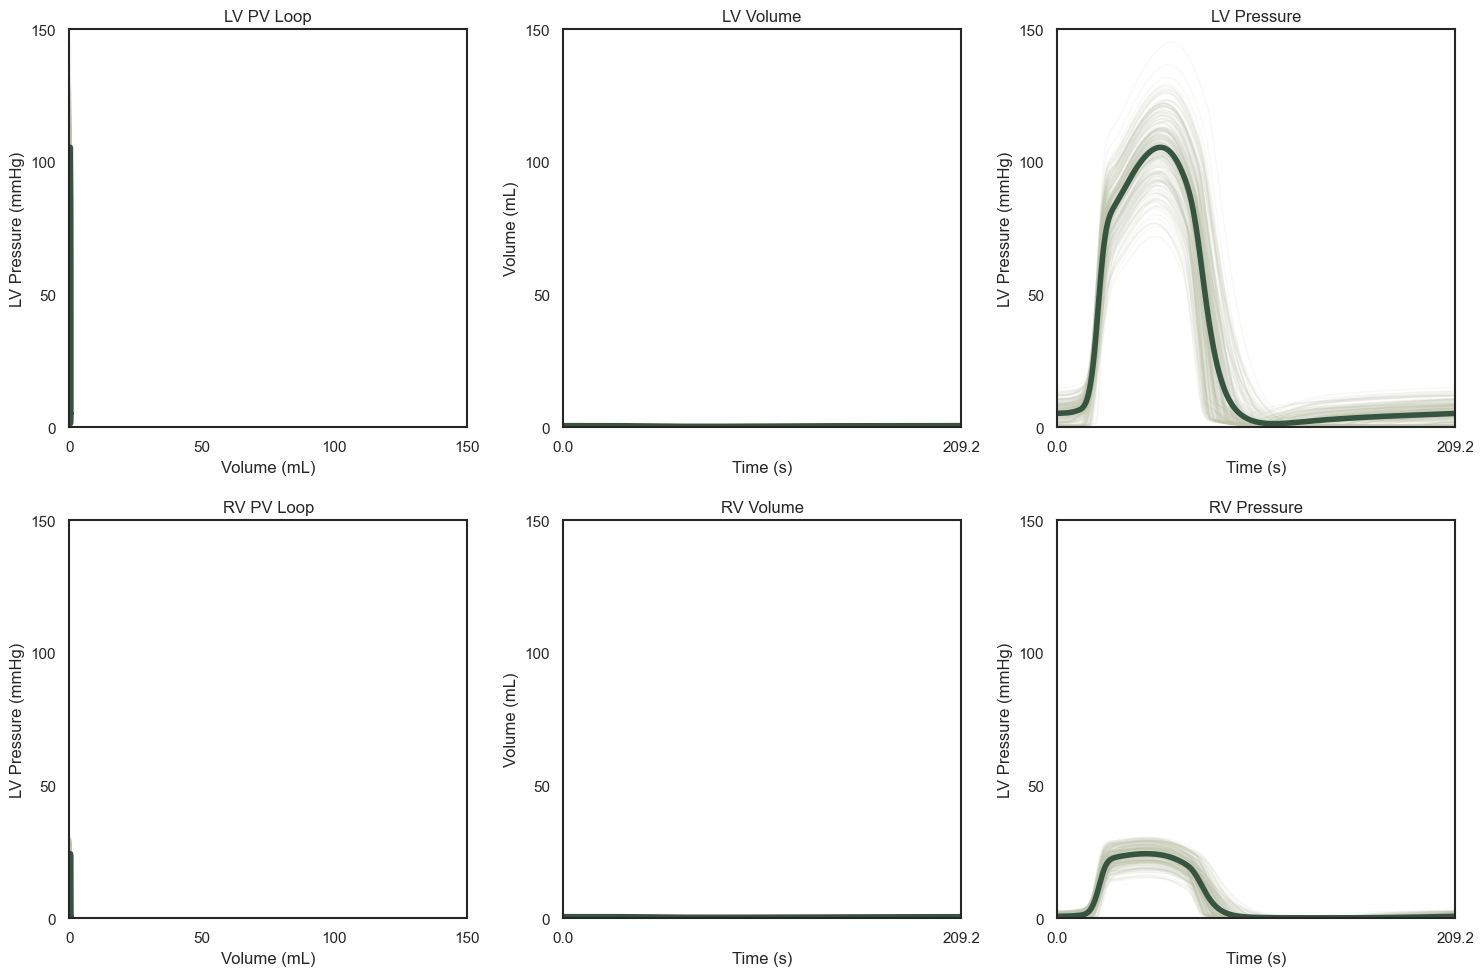

In [20]:
# Run simulations for all parameter sets in current wave set
wave.draw_posterior()
wave.x_posterior, wave.y_posterior, _ = monarch_utils.run_forest_run(wave, input_vo, [],  constants=model_constants, 
                                                         log_file=wave.log_file, show_hemo=True, posterior=True)

# Save the wave again to store the posterior results for plotting purposes
wave.pickle_wave()

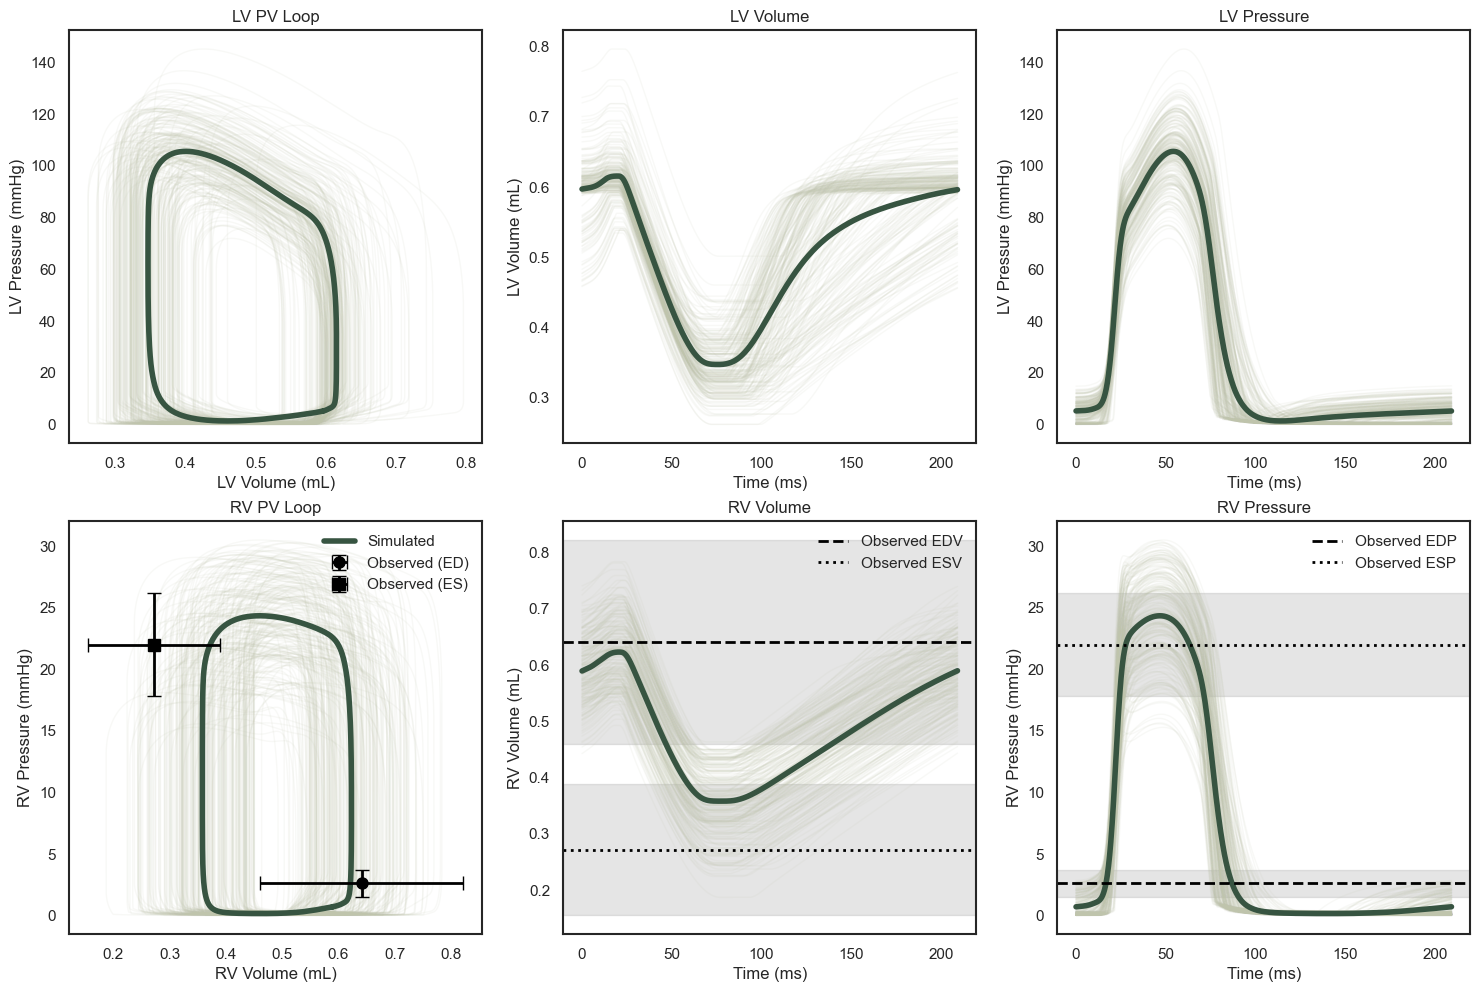

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import numpy as np
from pathlib import Path
import pandas as pd

# Load observed data
data_baseline = pd.read_csv("demo_monarch/data/data_baseline_P365_Nx.csv", index_col=0)

# Set up the plot
sns.set_theme(style="white", palette=None)
fig = plt.figure(figsize=(15, 10), linewidth=1.0)

# Get simulation files
posterior_dir = wave.dir.parent / wave.posterior_label
sim_files = sorted(list(posterior_dir.glob("*.hdf5")))
sim_files = [f for f in sim_files if '_acute' not in str(f)]

# Colors
color_space = "#bfc4ac"
color_main = "#375441"

# Load all simulation data
all_times, all_lv_volumes, all_lv_pressures = [], [], []
all_rv_volumes, all_rv_pressures = [], []

for sim_file in sim_files:
    with h5py.File(sim_file, "r") as f:
        time = f["time"][:] * 1e3
        lv_volume = f["volumes"][:, 2]
        lv_pressure = f["pressures"][:, 2]
        rv_volume = f["volumes"][:, 6]
        rv_pressure = f["pressures"][:, 6]
        
        all_times.append(time)
        all_lv_volumes.append(lv_volume)
        all_lv_pressures.append(lv_pressure)
        all_rv_volumes.append(rv_volume)
        all_rv_pressures.append(rv_pressure)

# Convert to arrays
all_times = np.array(all_times)
all_lv_volumes = np.array(all_lv_volumes)
all_lv_pressures = np.array(all_lv_pressures)
all_rv_volumes = np.array(all_rv_volumes)
all_rv_pressures = np.array(all_rv_pressures)

# Calculate min/max for RV from simulations
rv_edv_sim = all_rv_volumes.max(axis=1)
rv_esv_sim = all_rv_volumes.min(axis=1)
rv_edp_sim = all_rv_pressures[np.arange(len(all_rv_pressures)), all_rv_volumes.argmax(axis=1)]
rv_esp_sim = all_rv_pressures.max(axis=1)

# Get observed data
rvedv_mean = data_baseline.loc['RVEDV', 'mu_baseline']
rvedv_std = data_baseline.loc['RVEDV', 'sigma_baseline']
rvesv_mean = data_baseline.loc['RVESV', 'mu_baseline']
rvesv_std = data_baseline.loc['RVESV', 'sigma_baseline']
rvedp_mean = data_baseline.loc['RVEDP', 'mu_baseline']
rvedp_std = data_baseline.loc['RVEDP', 'sigma_baseline']
rvesp_mean = data_baseline.loc['RVMaxP', 'mu_baseline']
rvesp_std = data_baseline.loc['RVMaxP', 'sigma_baseline']

# Row 1: LV
ax1 = fig.add_subplot(2, 3, 1)
ax1.plot(all_lv_volumes.T, all_lv_pressures.T, linewidth=1.0, alpha=0.1, color=color_space)
ax1.plot(np.mean(all_lv_volumes, axis=0), np.mean(all_lv_pressures, axis=0), linewidth=4.0, color=color_main)
ax1.set_xlabel("LV Volume (mL)")
ax1.set_ylabel("LV Pressure (mmHg)")
ax1.set_title("LV PV Loop")

ax2 = fig.add_subplot(2, 3, 2)
ax2.plot(all_times.T, all_lv_volumes.T, linewidth=1.0, alpha=0.1, color=color_space)
ax2.plot(np.mean(all_times, axis=0), np.mean(all_lv_volumes, axis=0), linewidth=4.0, color=color_main)
ax2.set_xlabel("Time (ms)")
ax2.set_ylabel("LV Volume (mL)")
ax2.set_title("LV Volume")

ax3 = fig.add_subplot(2, 3, 3)
ax3.plot(all_times.T, all_lv_pressures.T, linewidth=1.0, alpha=0.1, color=color_space)
ax3.plot(np.mean(all_times, axis=0), np.mean(all_lv_pressures, axis=0), linewidth=4.0, color=color_main)
ax3.set_xlabel("Time (ms)")
ax3.set_ylabel("LV Pressure (mmHg)")
ax3.set_title("LV Pressure")

# Row 2: RV
ax4 = fig.add_subplot(2, 3, 4)
ax4.plot(all_rv_volumes.T, all_rv_pressures.T, linewidth=1.0, alpha=0.1, color=color_space)
ax4.plot(np.mean(all_rv_volumes, axis=0), np.mean(all_rv_pressures, axis=0), linewidth=4.0, color=color_main, label='Simulated')
# Add observed data points with error bars on PV loop
ax4.errorbar([rvedv_mean], [rvedp_mean], xerr=rvedv_std, yerr=rvedp_std, 
             fmt='o', color='black', markersize=8, linewidth=2, capsize=5, label='Observed (ED)', zorder=10)
ax4.errorbar([rvesv_mean], [rvesp_mean], xerr=rvesv_std, yerr=rvesp_std, 
             fmt='s', color='black', markersize=8, linewidth=2, capsize=5, label='Observed (ES)', zorder=10)
ax4.set_xlabel("RV Volume (mL)")
ax4.set_ylabel("RV Pressure (mmHg)")
ax4.set_title("RV PV Loop")
ax4.legend(frameon=False, loc='best')

ax5 = fig.add_subplot(2, 3, 5)
ax5.plot(all_times.T, all_rv_volumes.T, linewidth=1.0, alpha=0.1, color=color_space)
ax5.plot(np.mean(all_times, axis=0), np.mean(all_rv_volumes, axis=0), linewidth=4.0, color=color_main)
# Add observed EDV and ESV as horizontal lines
ax5.axhline(rvedv_mean, color='black', linestyle='--', linewidth=2, label='Observed EDV')
ax5.axhspan(rvedv_mean - rvedv_std, rvedv_mean + rvedv_std, alpha=0.2, color='gray')
ax5.axhline(rvesv_mean, color='black', linestyle=':', linewidth=2, label='Observed ESV')
ax5.axhspan(rvesv_mean - rvesv_std, rvesv_mean + rvesv_std, alpha=0.2, color='gray')
ax5.set_xlabel("Time (ms)")
ax5.set_ylabel("RV Volume (mL)")
ax5.set_title("RV Volume")
ax5.legend(frameon=False, loc='best')

ax6 = fig.add_subplot(2, 3, 6)
ax6.plot(all_times.T, all_rv_pressures.T, linewidth=1.0, alpha=0.1, color=color_space)
ax6.plot(np.mean(all_times, axis=0), np.mean(all_rv_pressures, axis=0), linewidth=4.0, color=color_main)
# Add observed EDP and ESP as horizontal lines
ax6.axhline(rvedp_mean, color='black', linestyle='--', linewidth=2, label='Observed EDP')
ax6.axhspan(rvedp_mean - rvedp_std, rvedp_mean + rvedp_std, alpha=0.2, color='gray')
ax6.axhline(rvesp_mean, color='black', linestyle=':', linewidth=2, label='Observed ESP')
ax6.axhspan(rvesp_mean - rvesp_std, rvesp_mean + rvesp_std, alpha=0.2, color='gray')
ax6.set_xlabel("Time (ms)")
ax6.set_ylabel("RV Pressure (mmHg)")
ax6.set_title("RV Pressure")
ax6.legend(frameon=False, loc='best')

# Make it look nice
for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
    ax.set_box_aspect(1.0)
    for axis in ['top', 'bottom', 'left', 'right']:
        ax.spines[axis].set_linewidth(1.5)
    ax.tick_params(width=1.5)

plt.tight_layout()
plt.show()

C:\Users\salla\AppData\Local\Temp\ipykernel_20368\2813832629.py:79: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend(frameon=False, loc='best')


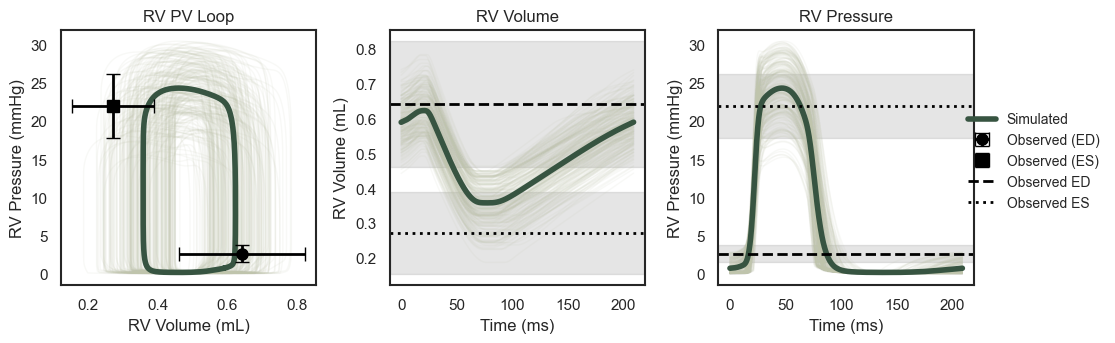

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import numpy as np
from pathlib import Path
import pandas as pd

# Load observed data
data_baseline = pd.read_csv("demo_monarch/data/data_baseline_P365_Nx.csv", index_col=0)

sns.set_theme(style="white", palette=None)
fig = plt.figure(figsize=(10, 4), linewidth=1.0)

posterior_dir = wave.dir.parent / wave.posterior_label
sim_files = sorted(list(posterior_dir.glob("*.hdf5")))
sim_files = [f for f in sim_files if '_acute' not in str(f)]

color_space = "#bfc4ac"
color_main = "#375441"

all_times, all_rv_volumes, all_rv_pressures = [], [], []

for sim_file in sim_files:
    with h5py.File(sim_file, "r") as f:
        time = f["time"][:] * 1e3
        rv_volume = f["volumes"][:, 6]
        rv_pressure = f["pressures"][:, 6]
        all_times.append(time)
        all_rv_volumes.append(rv_volume)
        all_rv_pressures.append(rv_pressure)

all_times = np.array(all_times)
all_rv_volumes = np.array(all_rv_volumes)
all_rv_pressures = np.array(all_rv_pressures)

rvedv_mean = data_baseline.loc['RVEDV', 'mu_baseline']
rvedv_std  = data_baseline.loc['RVEDV', 'sigma_baseline']
rvesv_mean = data_baseline.loc['RVESV', 'mu_baseline']
rvesv_std  = data_baseline.loc['RVESV', 'sigma_baseline']
rvedp_mean = data_baseline.loc['RVEDP', 'mu_baseline']
rvedp_std  = data_baseline.loc['RVEDP', 'sigma_baseline']
rvesp_mean = data_baseline.loc['RVMaxP', 'mu_baseline']
rvesp_std  = data_baseline.loc['RVMaxP', 'sigma_baseline']

ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(all_rv_volumes.T, all_rv_pressures.T, linewidth=1.0, alpha=0.1, color=color_space)
ax1.plot(np.mean(all_rv_volumes, axis=0), np.mean(all_rv_pressures, axis=0), linewidth=4.0, color=color_main, label='Simulated')
ax1.errorbar([rvedv_mean], [rvedp_mean], xerr=rvedv_std, yerr=rvedp_std,
             fmt='o', color='black', markersize=8, linewidth=2, capsize=5, label='Observed (ED)', zorder=10)
ax1.errorbar([rvesv_mean], [rvesp_mean], xerr=rvesv_std, yerr=rvesp_std,
             fmt='s', color='black', markersize=8, linewidth=2, capsize=5, label='Observed (ES)', zorder=10)
ax1.set_xlabel("RV Volume (mL)")
ax1.set_ylabel("RV Pressure (mmHg)")
ax1.set_title("RV PV Loop")
ax1.legend(frameon=False, loc='best')

ax2 = fig.add_subplot(1, 3, 2)
ax2.plot(all_times.T, all_rv_volumes.T, linewidth=1.0, alpha=0.1, color=color_space)
ax2.plot(np.mean(all_times, axis=0), np.mean(all_rv_volumes, axis=0), linewidth=4.0, color=color_main)
ax2.axhline(rvedv_mean, color='black', linestyle='--', linewidth=2, label='Observed ED')
ax2.axhspan(rvedv_mean - rvedv_std, rvedv_mean + rvedv_std, alpha=0.2, color='gray')
ax2.axhline(rvesv_mean, color='black', linestyle=':', linewidth=2, label='Observed ES')
ax2.axhspan(rvesv_mean - rvesv_std, rvesv_mean + rvesv_std, alpha=0.2, color='gray')
ax2.set_xlabel("Time (ms)")
ax2.set_ylabel("RV Volume (mL)")
ax2.set_title("RV Volume")
ax2.legend(frameon=False, loc='best')

ax3 = fig.add_subplot(1, 3, 3)
ax3.plot(all_times.T, all_rv_pressures.T, linewidth=1.0, alpha=0.1, color=color_space)
ax3.plot(np.mean(all_times, axis=0), np.mean(all_rv_pressures, axis=0), linewidth=4.0, color=color_main)
ax3.axhline(rvedp_mean, color='black', linestyle='--', linewidth=2)
ax3.axhspan(rvedp_mean - rvedp_std, rvedp_mean + rvedp_std, alpha=0.2, color='gray')
ax3.axhline(rvesp_mean, color='black', linestyle=':', linewidth=2)
ax3.axhspan(rvesp_mean - rvesp_std, rvesp_mean + rvesp_std, alpha=0.2, color='gray')
ax3.set_xlabel("Time (ms)")
ax3.set_ylabel("RV Pressure (mmHg)")
ax3.set_title("RV Pressure")
ax3.legend(frameon=False, loc='best')

for ax in [ax1, ax2, ax3]:
    ax.set_box_aspect(1.0)
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    ax.tick_params(width=1.5)

# Collect handles from all axes
handles, labels = [], []
for ax in [ax1, ax2, ax3]:
    h, l = ax.get_legend_handles_labels()
    handles += h
    labels += l

# Deduplicate
seen = set()
unique = [(h, l) for h, l in zip(handles, labels) if not (l in seen or seen.add(l))]
handles, labels = zip(*unique)

# Remove individual legends
for ax in [ax1, ax2, ax3]:
    ax.get_legend().remove()

# Add single legend outside figure on the right
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.12, 0.5),
           frameon=False, fontsize=10)

plt.tight_layout()
plt.show()

In [23]:
import pandas as pd
import numpy as np

# wave.nroy is typically an array of shape (n_survivors, n_params)
# pars contains the parameter names

nroy_df = pd.DataFrame(wave.nroy, columns=pars)

# Summary statistics
summary = nroy_df.describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
summary.columns = ['Mean', 'Std', 'Min', 'Q25', 'Median', 'Q75', 'Max']

print(summary.to_string())

                Mean        Std         Min         Q25      Median         Q75         Max
AmRefRfw  457.160997  22.062013  425.000381  439.144897  453.676224  471.755219  524.998093
Cvs         1.071131   0.271403    0.372497    0.856498    1.096236    1.303953    1.499995
Rap         7.613560   3.564127    2.000019    4.551311    7.266571   10.435043   14.999950
sfact       0.670080   0.210655    0.200061    0.505695    0.690564    0.850586    0.999988
c3          0.022093   0.014356    0.000050    0.009418    0.020626    0.033994    0.050000


In [30]:
import pickle
import pandas as pd
from pathlib import Path

def save_posterior_from_wave(wave, input_vo, output_dir="results/posterior_csvs"):
    """
    Extract posterior parameter samples from the final wave and save to CSV.
    Automatically uses whatever parameters were calibrated (x_names).
    Named after input_vo so it works for any group/age combination.
    
    Parameters
    ----------
    wave      : your wave object (already loaded)
    input_vo  : string name of your json input file e.g. "P21_Hx"
    output_dir: where to save the CSV
    """
    # Find and load the final wave pkl
    baseline_dir = wave.dir.parent
    wave_dirs = sorted(baseline_dir.glob("Wave *"))
    final_wave_pkl = wave_dirs[-1] / "wave.pkl"
    
    with open(final_wave_pkl, 'rb') as f:
        final_wave = pickle.load(f)

    # Use x_names directly — works regardless of which parameters were calibrated
    param_names = final_wave.x_names
    print(f"Calibrated parameters found: {param_names}")

    # Build DataFrame
    df = pd.DataFrame(final_wave.x_posterior, columns=param_names)
    df.insert(0, 'input_vo', input_vo)

    # Save
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    save_path = output_dir / f"posterior_samples_{input_vo}.csv"
    df.to_csv(save_path, index=False)
    
    print(f"Saved {len(df)} posterior samples for '{input_vo}'")
    print(f"Location: {save_path}")
    print(df.head())
    return df

# ── Run this at the end of every calibration notebook ────────────────────────
# ... your calibration code ...

save_posterior_from_wave(wave, input_vo)

Calibrated parameters found: ['AmRefRfw', 'Cvs', 'Rap', 'sfact', 'c3']
Saved 238 posterior samples for 'P365_Nx'
Location: results\posterior_csvs\posterior_samples_P365_Nx.csv
  input_vo    AmRefRfw       Cvs       Rap     sfact        c3
0  P365_Nx  462.701797  1.392265  6.309414  0.893106  0.045035
1  P365_Nx  426.455307  1.077010  5.049503  0.688937  0.045157
2  P365_Nx  435.610199  0.771791  3.922844  0.485577  0.035723
3  P365_Nx  430.569077  0.894320  8.643864  0.779855  0.031309
4  P365_Nx  431.781769  1.475145  4.647865  0.937836  0.019900


,input_vo,AmRefRfw,Cvs,Rap,sfact,c3
0,P365_Nx,462.701797,1.392265,6.309414,0.893106,0.045035
1,P365_Nx,426.455307,1.077010,5.049503,0.688937,0.045157
2,P365_Nx,435.610199,0.771791,3.922844,0.485577,0.035723
3,P365_Nx,430.569077,0.894320,8.643864,0.779855,0.031309
4,P365_Nx,431.781769,1.475145,4.647865,0.937836,0.019900
...,...,...,...,...,...,...
233,P365_Nx,489.557266,1.319804,8.175625,0.622012,0.003719
234,P365_Nx,478.639603,1.460688,10.570477,0.783817,0.039271
235,P365_Nx,431.443405,1.229259,3.798420,0.967953,0.021013
236,P365_Nx,438.101959,0.787065,12.030586,0.753192,0.031060


Note how nicely the simulations are centered around the mean values we were trying to match. We can compare it better to the data using the TrueColors class. Start by comparing the posterior metrics to the data:

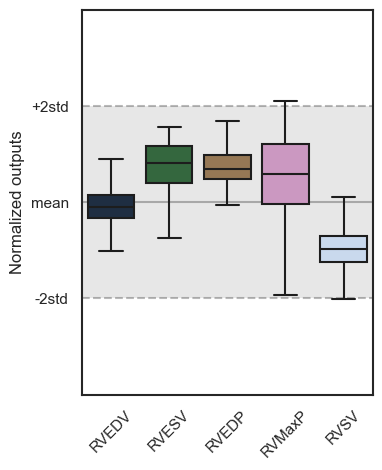

In [26]:
from chameleon import TrueColors

colors = TrueColors(baseline_dir)

# Plot the convergence of the implausibility
colors.plot_nroy_data(show_box=True)

Next, inspect the final NROY region to inspect if all parameters are uniquely fitted, and if the mean of the matched distribution is close to the true values in this synthetic case. This plot is time-consuming to generate, so we here run it with a subset of 5000 randomly chosen parameter sets.

In [27]:
#colors.plot_nroy_x(n_samples=5000, show_fig=True)

Note how the calibrated parameter distributions are unimodal and nicely centered around the ground truth value. Run all plots, this will be time-consuming–in fact, it is slower than running BHM itself! The plots are saved in the *results* subdirectory.

In [28]:
#colors.roll(nroy_full=False)

Finally, run all plots. This will take a while, so be patient. The plots are saved in the *results* subdirectory.

In [29]:
#colors.roll(nroy_full=False)

## References
[1] Jones, C. E. & Oomen, P. J. A. Synergistic Biophysics and Machine Learning Modeling to Rapidly Predict Cardiac Growth Probability. bioRxiv 2024.07.17.603959 (2024) doi:10.1101/2024.07.17.603959.